In [ ]:
#
#########################
# Veri Seti
#########################

# Veri seti hakkında


# Veri seti hakkında Kaggle'da yer alan bilgiler
#Başlık: Banka Pazarlaması

#Kaynaklar
#Hazırlayanlar: Paulo Cortez (Minho Üniversitesi) ve Sérgio Moro (ISCTE-IUL) @ 2012

#Geçmiş Kullanım:
#Veri setinin tamamı şu çalışmada tanımlanmış ve analiz edilmiştir:
#S. Moro, R. Laureano ve P. Cortez. Banka Doğrudan Pazarlamasında Veri Madenciliği Kullanımı: CRISP-DM Metodolojisi Uygulaması.
#P. Novais ve diğerleri (Ed.), Avrupa Simülasyon ve Modelleme Konferansı - ESM'2011 Bildirileri, s. 117-121, Guimarães,
#Portekiz, Ekim 2011. EUROSIS.

#İlgili Bilgiler:

#Veriler, Portekizli bir bankacılık kurumunun doğrudan pazarlama kampanyalarıyla ilgilidir.
#Pazarlama kampanyaları telefon görüşmelerine dayanıyordu. Ürünün (banka vadeli mevduat hesabı) satın alınıp alınmayacağını
#belirlemek için genellikle aynı müşteriyle birden fazla kez temas kurulması gerekiyordu.

#İki veri seti bulunmaktadır:
#1) Tarihe göre sıralanmış (Mayıs 2008'den Kasım 2010'a kadar) tüm örnekleri içeren bank-full.csv.
#2) bank-full.csv içinden rastgele seçilen örneklerin %10'unu (4521 adet) içeren bank.csv.
  #Daha küçük olan veri seti, hesaplama açısından daha yoğun kaynak gerektiren makine öğrenimi algoritmalarını
  #(ör. SVM) test etmek amacıyla sağlanmıştır.

#Sınıflandırma hedefi, müşterinin vadeli mevduat hesabı açıp açmayacağını (y değişkeni) tahmin etmektir.

#Örnek Sayısı: bank-full.csv için 45211 (bank.csv için 4521)

#Öznitelik Sayısı: 16 + çıktı özniteliği.

#Öznitelik bilgileri:

#Daha fazla bilgi için [Moro ve diğerleri, 2011] çalışmasını inceleyin.


# Veri seti boyutu: gözlem sayısı 45211,değişken sayısı:17
#Değişken isimleri ve taşıdığı bilgileri açıklaması

#Girdi değişkenleri:

#Müşteri kişisel bilgileri

#değişken ismi/veri tipi

#1. age(yas)/(numeric)
 #(min :18,max:95)

#2.job (musteri_meslek) /  (categorical:nominal(sırasız))
 #12 farklı pozisyon türü var(belirlenmemiş dahil(unknown))
 #("admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
 #"blue-collar","self-employed","retired","technician","services")

#3.marital(medeni_durumu)/(categorical: nominal(sırasız))
 #3 farklı (evl,bekar,ayrılmış veya dul)
 #"married","divorced","single"; note: "divorced" means divorced or widowed)

#4.education (egitim_bilgisi /(categorical: nominal(sıralı))
 # 4farklı (belirlenmemiş veya bilgisi verilmiş olan unknown dahil)
 #("unknown","secondary","primary","tertiary"))

#5.default  (temerrut_durumu)/(binary: "yes","no")
 #temerrüde düşmüş kredisi var mı?*

#6.balance  (eur_yillik_ortalama_bakiye)/ (numeric)
 #euro biriminden hesabındaki yıllık ortalama para

#7.housing (konut_kredi_durumu)/(binary: "yes","no")
 #konut kredisi var mı?*/

#8.loan (bireysel_kredi_durumu)/(binary: "yes","no")
 #Bireysel çektiği  kredi var mı?

#9 .contact (iletisim_kanali) / (categorical:nominal(sırasız))
 # müşteriye ıletişime geçtiği kanal türü/ :3 farklı
 #("unknown","telephone(sabit telefon üzerinden)","cellular(cep telefon üzerinden)"))

#10.day (son_temas_gun)/ (numeric)
 # en son iletişime geçildiğinde ayın hangi günü iletişime geçildiği

#11. month (son_temas_ay)/(categorical: "jan", "feb", "mar", …, "nov", "dec")
 #son gorüştüğü tarih (ay  olarak)bilgisi
 # BUNU object yapmamız gerekir konuşalım

#12.duration (konusma_Suresi/ (numeric)
 #müşteri ile son gorüşülen konuşma  süre(saniye olarak) /


#13.campaign (kampanya_temas_sayisi) /numeric
 #Bu kampanya sırasında ve bu müşteri için gerçekleştirilen temas sayısı(son temas dahil))

#14.pdays(son_iletisimden_gecen_gun) /numeric
 # önceki kampanya döneminde son iletişime geçildiği zamandan bu yana geçen gün sayısı.
 # -1 müşteriyle daha önceden hiç iletişime geçilmediği anlamındadır.*

# Hasan's offfer create a new column called as previously contacted? -1's of pdays will craeate 1's (yes) others will be 0 (not previousy contacted user)

#BU DEĞİŞKEN O ZAMAN taşıdığı bilgi bakımından numerik olması doğru olur mu? Numerik kalmaması gerekir mi ? veya
# bu veri seti ile hangi probelemi çözeceğiz ki kategorik veri tipine çevirelim
#           count         mean          std     min      0%     5%    50%     95%      99%      100%       max
#pdays     45211.0    40.197828   100.128746    -1.0    -1.0   -1.0   -1.0   317.0    370.0     871.0     871.0
#
 #BU DEĞİŞKEN bizin için önemli bilgi taşıyacak :Recency değer açıklıyor.

#ŞUAN Pdyas'i bölmek için YAPILMASI GEREKENLER
#Değişken değerleri detaylı incelememiz gerekiyor
#1 ADIM:
# İletişime geçilmemiş( pdays değişkende -1 girilen satırların toplamı kaç ) olanları toplam sayısı
#2.ADIM:
# -1 hariç toplam gözlem sayısı
#3.ADIM:
#gün sayısı toplamı:
 #"0-30(30 dahil)olan gözlemleri toplamı
 #"31 - 90(90 dahil) olan gözlemlerin toplamı
 # 91-120(120 dahil)olan  olan gözlemlerin toplamı
 # 121+ üzeri olan gözlemlerin toplamı



# Iş Problemimiz başlığını netleştirdiğimizden sonra bu değişken nasıl kullanacağımız karar verilir
#İŞ PROBLEMİMİZ NETLEŞİNCE UYGULARIZ BELKİ,ŞUAN YAPMAYALIM AŞAĞIDAKİ ADIMLARI

#ÇÖZÜM:



#1.Kategorik Gruplama (Binning):FEATURE ENGİNNERING UYGULANACAK(aşağıdakı 5 farklı değişken elde edilecek)
 #(Hiç iletişime geçilmeyenler):
 #"0-30(30 dahil)olan gözlemleri toplam
 #"31 - 90(90 dahil) olan gözlemlerin toplamı
 # 91-120(120 dahil)olan  olan gözlemlerin toplamı
 # 121+ üzeri olan gözlemlerin toplamı

# * 1. nin kullnaılması kesin karar kılındı. 5/09/2026

#2.İkili kodlama (Binary encoding yapılacak)
 # Daha_Once_Iletisim_Kuruldu_mu adında bir sütun açılır. -1 olanlar için 0 (Hayır),
 #diğer tüm sayılar için 1 (Evet) yazılır.

# * Modelleme aşamasında 2.nin yapılıp yapılmayacağına karar verielcek 5/09/2026


#Çözüm başlığı altında yazdıklarım fikir olarak paylaşmak istedim,şuanlık sadece

#15.previous (onceki_kampanya_temas_sayisi) / (numeric)
 # bu kampanya öncesinde  müşteriyle  gerçekleştirilen iletişim sayısı
#16.poutcome (onceki_vadeli_mevduat_durumu) /(categorical
 # Önceki pazarlama kampanyası döneminde vadeli mevduat hesabı açıp açmadığı bilgisi*
 # 4 farklı durum:("unknown","other","failure","success")


#Hedef değişkeni(çıktı değişken)
#17.y (subscription_status)/ (binary: "yes","no")
#Müşterinin Sonuçta Vadeli mevduat hesabı açıp açtırmadığı bilgisi*


# 17 numaranın bağımlı  değişken olduğunu düşünüyorum. ->Evet




In [ ]:
#
#########################
# İş Problemi
#########################

# Seçenek 1
#Elimizdeki veri seti ile banka vadeli mevduat hesabı satıp satmadığını  tahmin eden ML model çalışması yapmak

#Seçenek2



In [ ]:

#
#########################
# Gerekli kütüphaneler eklenmesi
#########################
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



pd.set_option('display.max_columns', None) # tüm sütünları görmek için


In [ ]:
from google.colab import files
uploaded = files.upload() # veri seti dosyayı çalışma ortalama yüklemek ve hızlıca okutma için kestirme yol

Saving bank-full_edited.csv to bank-full_edited.csv


In [ ]:
df_original= pd.read_csv("bank-full.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## ** colab her yeni açılışında her şeye baştan başladığı için buraya kadar ****
# datasetimizde yaptığımız değişiklikleri kaydedelim.
import os
os.makedirs("Bank_Dataset", exist_ok=True)
df.to_csv("Bank_Dataset/bank-full_edited.csv",index=False )
# Artık bunu (bank-full_edited) yükleyelim ve bununla devam edelim.
df= pd.read_csv("/content/drive/MyDrive/Data_Science/Final_Project/bank-full_edited.csv")
### *************************************************************************

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Data_Science/Final_Project/bank-full_edited.csv'

In [ ]:
#Yulduz
#07.09.2026
# bu kod aşamadan önce en son projeyi yollarken orijinal veri seti üzerinden yapılan adımlar ekleyelim
from google.colab import files
files.download('bank-full_edited.csv') # y sütünün düzenlenmiş halindeki bank-full_edited.csv dosyayı pc indirme

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
df= pd.read_csv("bank-full_edited.csv")
print(df["subscription_status"].value_counts())

subscription_status
no     39922
yes     5289
Name: count, dtype: int64


In [ ]:
#Dengesiz veri setindeki hedef değişkeni düzenleme çalışması:
# subscription_status
# no     39922
# yes     5289
# as can be seen from above. subscription_status column
# of The dataset bank-full_edited.csv is unbalanced
# In below the dataset is balanced by captruing rows which their specs given below
# 1) all rows which contains subscription_status as yes
# 2) random selected 1905 rows which contains subscription_status as "no "and  pdays values > -1
# 3) random selected 3384 rows which contains subscription_status as "no "and  pdays values as -1

In [ ]:
#Hedef değişken için dengelenmesi için uygulanan adımlar:
df_balanced=df[(df["subscription_status"]=="yes")]
df_rand_no_old_customer=df[(df["subscription_status"]=="no") & (df["pdays"] >-1)].sample(n=1905)
df_rand_no_new_customer=df[(df["subscription_status"]=="no") & (df["pdays"] ==-1)].sample(n=3384)
df_randoms_no_concated_=pd.concat([df_rand_no_old_customer,df_rand_no_new_customer],ignore_index=True)
df_balanced=pd.concat([df_balanced,df_randoms_no_concated_],ignore_index=True)
# end of dataset balancing
# saving the balanced dataset

In [ ]:


from google.colab import files
files.download('Bank_Dataset/bank-full_balanced.csv')
# End of downloading
uploaded = files.upload() # Uploading the downloaded file
df_blncd_upld= pd.read_csv("bank-full_balanced.csv") # Reading the file

In [ ]:
#KEŞİFSEL VERİ ANALİZİ
####**** EDA***********************###########################################
def check_dataframe(dataframe, head=5):
 print("##col_names##")
 print(dataframe.columns)
 print("###shape###")
 print(dataframe.shape)
 print("###datatypes###")
 print(dataframe.dtypes)
 print("###head###")
 print(dataframe.head(head))
 print("###tail###")
 print(dataframe.tail(head))
 print("###frequneceofnullsbycolumns###")
 print(dataframe.isnull().sum())
 print("###quantiles-dağılımlar###")
 print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)
 print("#Numeriklerin sayımlı (istatistik) anlamında özet bilgisi.")
 print(dataframe.describe().T )
 print("# Tipi object olanların (istatistik) anlamında özet bilgisi")
 print(dataframe.describe(include=["object"]).T)
 print("# Tipi category olanların (istatistik) anlamında özet bilgisi")
 print(dataframe.describe(include=["category"]).T)
 print("##info##")
 print(dataframe.info())

check_dataframe(df_blncd_upld)

# Notlar: Önceden Hiç iletişime geçilmeyenlerin balance değeri ne girilmiş crosstab ile bakılacak.

# Veri tipi incelemesi:
#category( ordered=False):job,marital,default,housing,loan,subscription_status, poutcome, contact
#category( ordered=True): 'education

df_blncd_upld["education"] = pd.Categorical(df_blncd_upld["education"],
                                            categories= ["unknown","primary","tertiary","secondary"],
                                            ordered=True)
convert_list= ["job","marital","default","housing","loan","subscription_status", "poutcome", "contact"]
for c in convert_list:
  df_blncd_upld[c] = pd.Categorical(df_blncd_upld[c], ordered=False)


# Sayısal değişken incelemesi---- Notlar: Önceden Hiç iletişime geçilmeyenlerin balance değeri ne girilmiş crosstab ile bakılacak.
# yaşı 18 olup poutcome'ı successfull olan var mı bak
# duration campaign age previous için aykırı değer var baskılamak gerek ayrıntısına görselleştirmedde bak
# Kategorik değişken incelemesi---- Notlar:
# pdays ile poutcome 2 li incelemede görüldü ki pdays -1  olan 36954 poutcome unknown olan 36959 .
#59-54=5 kişiye önceden erişilmiş ancak öncek kampnayadan subs_stat verisi bilnmiyor.

#pdays'den 5 farklı sütun çıkartacağız--> Feature Engineering
#1.sinin adı previously contacted? pdays=-1 olanlar "no" pdays > -1 yes olacak şekilde içeriği olsun.
#pdays
#pdays 0-30(30 dahil)olanlar true diğerleri false
 #"pdays 31 - 90(90 dahil) olanlar true diğerleri false
 # pdays 91-120(120 dahil)olanlar  true diğerleri false
 # pdays 121+ üzeri olanlar true diğerleri false

df_blncd_upld["previously_contacted?"]= [ "No" if c == -1 else "Yes"  for c in df_blncd_upld["pdays"]]

df_blncd_upld["pdays_[0,30]"]= [ "Yes" if c>=0 and c<=30 else "No"  for c in df_blncd_upld["pdays"]]

df_blncd_upld["pdays_[31,90]"]= [ "Yes" if c>=31 and c<=90 else "No"  for c in df_blncd_upld["pdays"]]

df_blncd_upld["pdays_[91,120]"]= [ "Yes" if c>=91 and c<=120 else "No"  for c in df_blncd_upld["pdays"]]

df_blncd_upld["pdays_>120}"]= [ "Yes" if c>=121 else "No"  for c in df_blncd_upld["pdays"]]



# now we will continue with the dataset df_blncd_upld by restarting from EDA
check_dataframe(df_blncd_upld)



##col_names##
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'subscription_status', 'previously_contacted?', 'pdays_[0,30]', 'pdays_[31,90]', 'pdays_[91,120]', 'pdays_>120}'], dtype='object')
###shape###
(10578, 22)
###datatypes###
age                         int64
job                      category
marital                  category
education                category
default                  category
balance                     int64
housing                  category
loan                     category
contact                  category
day                         int64
month                      object
duration                    int64
campaign                    int64
pdays                       int64
previous                    int64
poutcome                 category
subscription_status      category
previously_contacted?      object
pdays_[0,30]               object

In [ ]:


print(df_blncd_upld.isnull().values.any()) # As we can see from outcomes of check_df function
# In the dataset there is no obvious null value .
# Now we will check if thre is any hidden null value

# ******Gizli null inceleme sonrası notlar***
## Job'da 288 unknown var. % 0.637013'e karşılık geliyor.
## education'da 1857 unknown var. % 4.107407'e karşılık geliyor.
## contact'de 13020 unknown var. % 28.798301'e karşılık geliyor.
## pdays'de -1  var. Müşteriyle önceden iletişime geçilmediği anlamında
# -1 'lerin sayısı ve yüzdesi:36954 % 81.736745
## poutcome'de 36959 unknown var. % 81.747805'e karşılık geliyor.
# --> önceden görüşülmeyenler 36954 önceki pazarlama kampanyasında vadeli
# açıp açmadığı bilinmeyenler 36959. Yani 36959- 36954= 5--> bu kampnayadan
# önce görüşülüp, yine de önceki dönem vadeli mevduat açıp/açmadığı bilinmeyenler
# 5 kişi--> bu noktada verinin kaliteli olduğunu gösterir.

# Frequences and portion in percent of feature (column) classes.
for c in df_blncd_upld.columns:
  print(df_blncd_upld[c].value_counts())
  print("Yüzdelik oran",100*df_blncd_upld[c].value_counts()/ len(df_blncd_upld))

age
32    472
33    458
35    433
36    429
34    425
     ... 
87      3
90      2
92      2
93      2
95      1
Name: count, Length: 74, dtype: int64
Yüzdelik oran age
32    4.462091
33    4.329741
35    4.093401
36    4.055587
34    4.017773
        ...   
87    0.028361
90    0.018907
92    0.018907
93    0.018907
95    0.009454
Name: count, Length: 74, dtype: float64
job
management       2433
blue-collar      1876
technician       1716
admin.           1258
services          880
retired           741
student           377
self-employed     365
entrepreneur      319
unemployed        302
housemaid         247
unknown            64
Name: count, dtype: int64
Yüzdelik oran job
management       23.000567
blue-collar      17.734922
technician       16.222348
admin.           11.892607
services          8.319153
retired           7.005105
student           3.564001
self-employed     3.450558
entrepreneur      3.015693
unemployed        2.854982
housemaid         2.335035
unknown         

In [ ]:
#Veri setindeki değişken türlerin incalenmesi

def grab_col_names(dataframe, cat_th=10,  car_th=20):
    """
    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.

    Parameters
    ----------
    dataframe: dataframe
        değişken isimleri alınmak istenen dataframe'dir.
    cat_th: int, float
        numerik fakat kategorik olan değişkenler için sınıf eşik değeri
    car_th: int, float
        kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    -------
    cat_cols: list
        Kategorik değişken listesi
    num_cols: list
        Numerik değişken listesi
    cat_but_car: list
        Kategorik görünümlü kardinal değişken listesi

    Notes
    ------
    cat_cols + num_cols + cat_but_car = toplam değişken sayısı
    num_but_cat cat_cols'un içerisinde.

    """
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < 10 and dataframe[col].dtypes in ["int", "float"]]

    cat_but_car = [col for col in dataframe.columns if
                   dataframe[col].nunique() > 20 and str(dataframe[col].dtypes) in ["category", "object"]]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int", "float"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


# Düzenleme sonucu teyit için:
# 17 değişkenin veri tipi dağılımı:
 #object tipi değişken sayısı:1 :month
 #sayısal değişken sayısı:6
 #kategorik değişken sayısı:10
  # sıralı bilgi taşıyan değişken sayısı ve ismi:1 ve education ; #kalan değişken :9 sırasız
  # 9 değişkenden :
      # ikili bilgi içeren (yes/no ) sayısı ve ismi:4: loan,default,subscription_status,housing
      # 2'den çok(2+) kategori bilgisi taşıyan ve aralarında sıra olmayan değişken sayısı 6 :contact,poutcome,job,marital,pdays(düzenlenmiş hali)
# pdays'i dzüenlereken order false olacak.

cat_cols, num_cols, cat_but_car = grab_col_names(df_blncd_upld)

Observations: 10578
Variables: 22
cat_cols: 15
num_cols: 7
cat_but_car: 0
num_but_cat: 0


In [ ]:
print(num_cols) # sayısal bilgi taşıyan değişkenler

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
print(cat_cols)  # burda hangileri category( ordered=False) ,category( ordered=True) ,object olmalı


# pandasta object ve category ikisi de kategoriktir.
# bir değişkenin object ve category olması arasında bazı fonksiyonlar için fark var.
# ama genel olarak aynı



# category yapmak  için yes/no bilgisi taşıyan loan ve subscr0iption_status gibi değişkenlerimizi sayısal olarak 1/0 olarak kodlarsak(yani label etkiketleme yapıldığında) ilerde model oluşturmadan önce
# bu değişkenleri tipini de category( ordered=False) yapısına çeviririz,çünkü sıralama bilgisi taşımıyor. object ve category veri tipi farkını bu şekilde diye hatırlıyorum



#object' çevrilcek :month,
#category( ordered=False):job,marital,default,housing,loan,subscription_status, poutcome, contact
#category( ordered=True): 'education

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'subscription_status', 'previously_contacted?', 'pdays_[0,30]', 'pdays_[31,90]', 'pdays_[91,120]', 'pdays_>120}']


In [ ]:
df_blncd_upld.index

print(df_blncd_upld[cat_cols].nunique())
[print(df_blncd_upld[c].value_counts()) for c in cat_cols ]

print(100 * df_blncd_upld["subscription_status"].value_counts() / len(df_blncd_upld))
print(100 * df_blncd_upld["education"].value_counts() / len(df_blncd_upld))


job                      12
marital                   3
education                 4
default                   2
housing                   2
loan                      2
contact                   3
month                    12
poutcome                  4
subscription_status       2
previously_contacted?     2
pdays_[0,30]              2
pdays_[31,90]             2
pdays_[91,120]            2
pdays_>120}               2
dtype: int64
job
management       2433
blue-collar      1876
technician       1716
admin.           1258
services          880
retired           741
student           377
self-employed     365
entrepreneur      319
unemployed        302
housemaid         247
unknown            64
Name: count, dtype: int64
marital
married     5934
single      3410
divorced    1234
Name: count, dtype: int64
education
secondary    5196
tertiary     3535
primary      1406
unknown       441
Name: count, dtype: int64
default
no     10443
yes      135
Name: count, dtype: int64
housing
no     5414


In [ ]:
print(100 * df_blncd_upld["subscription_status"].value_counts() )

subscription_status
no     3992200
yes     528900
Name: count, dtype: int64


In [ ]:
print(100 * df_blncd_upld["subscription_status"].value_counts() / len(df_blncd_upld))

subscription_status
no     88.30152
yes    11.69848
Name: count, dtype: float64


In [ ]:
#############################################
# VERİ GÖRSELLEŞTİRME
#############################################
# Kategorik değişken: sütun grafik. countplot bar
# Sayısal değişken: hist, boxplot


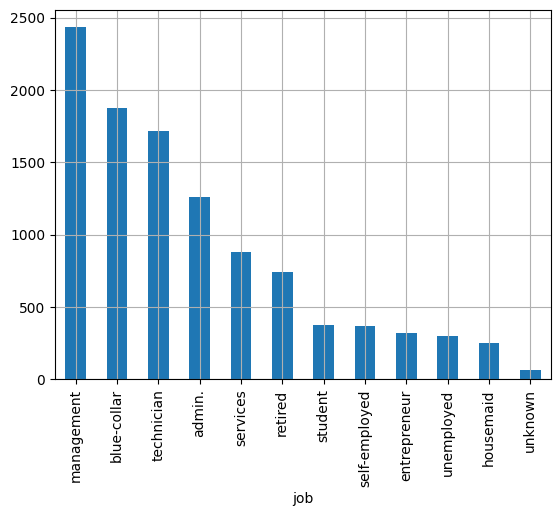

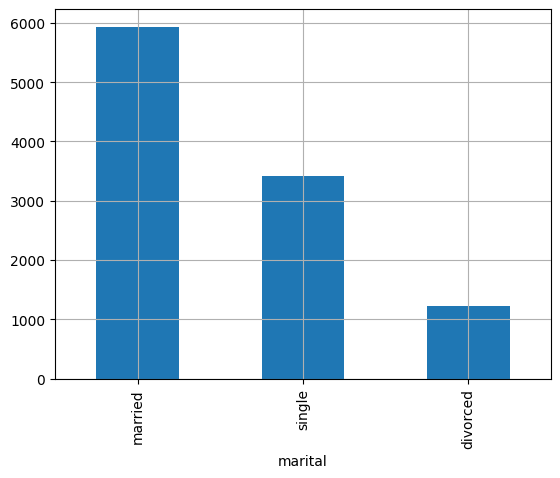

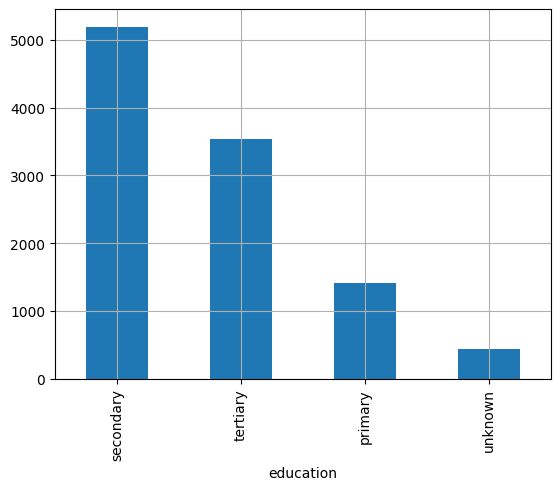

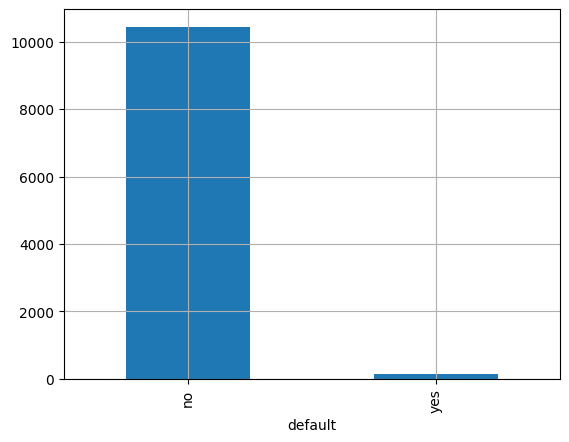

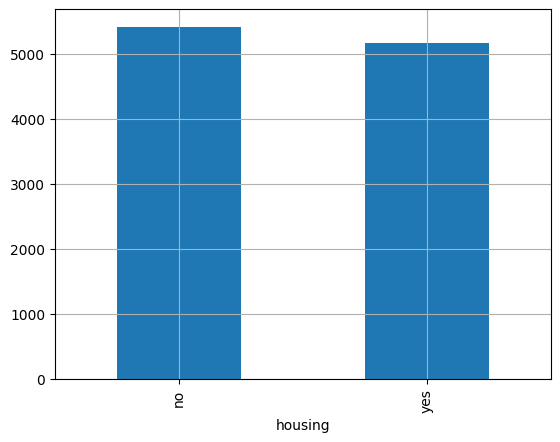

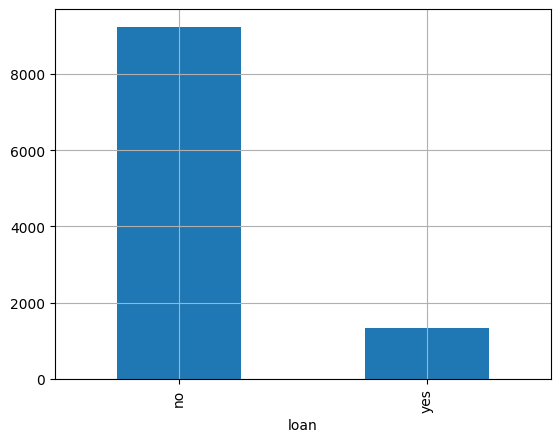

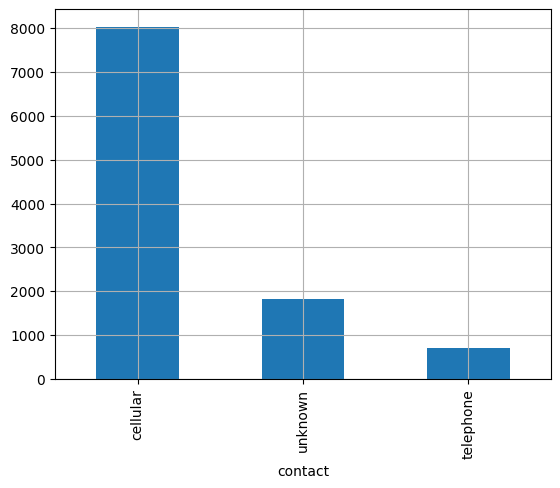

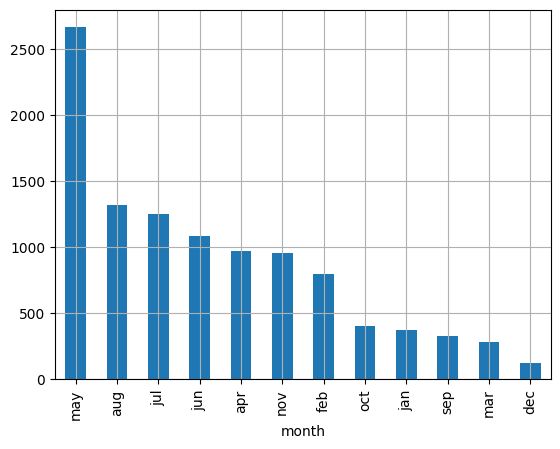

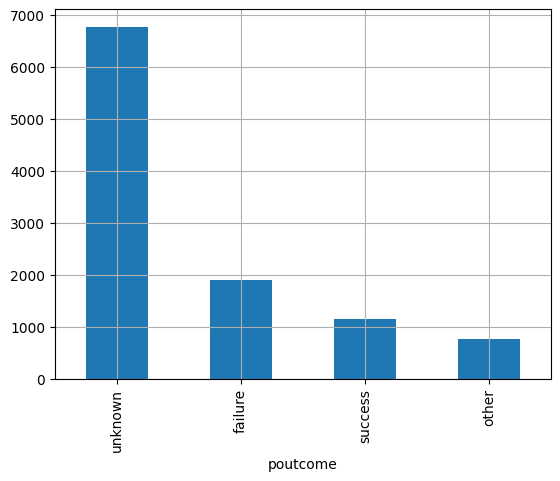

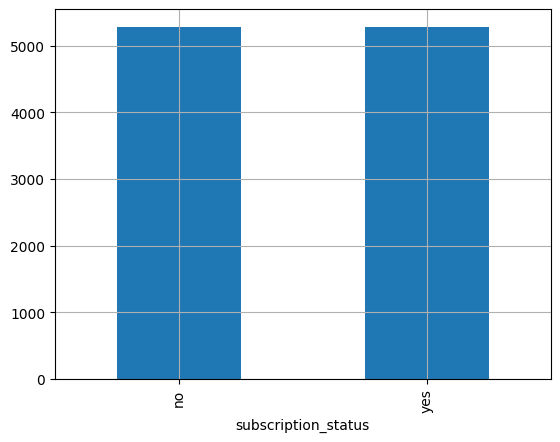

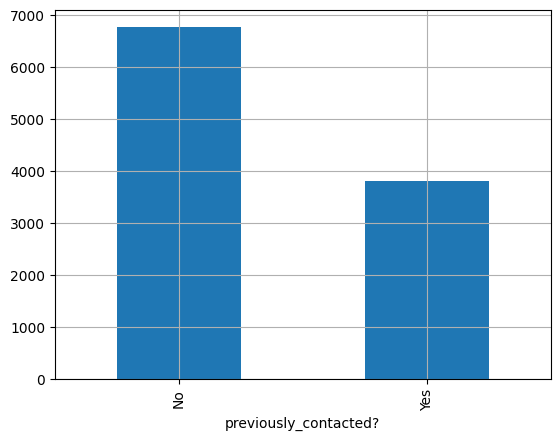

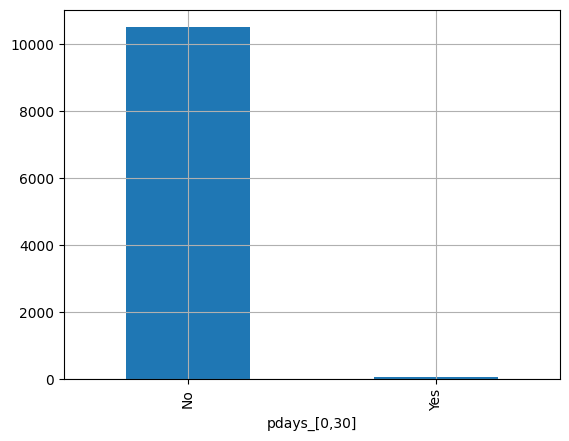

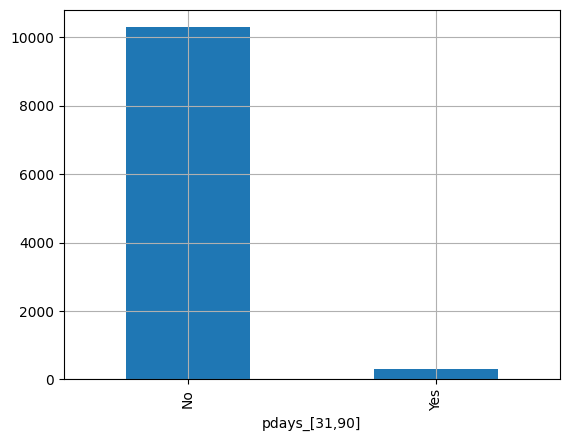

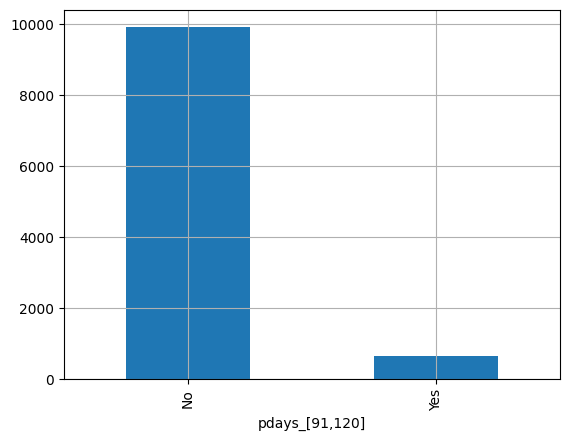

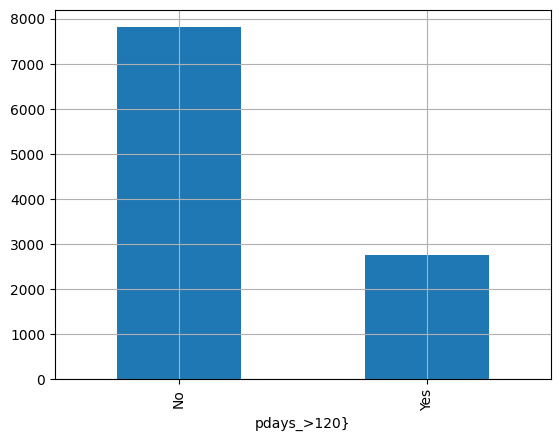

In [ ]:

####
# kategroik değişken görselleştirme
#####

for c in cat_cols:
  df_blncd_upld[c].value_counts().plot(kind="bar")
  plt.grid()
  plt.show()

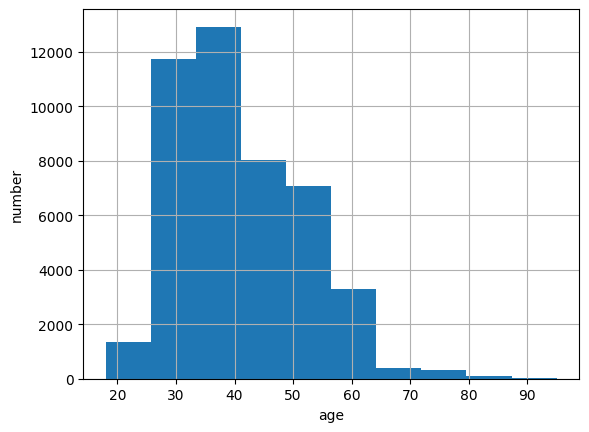

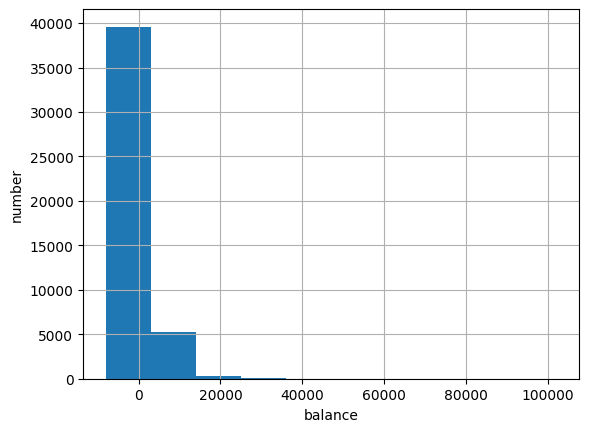

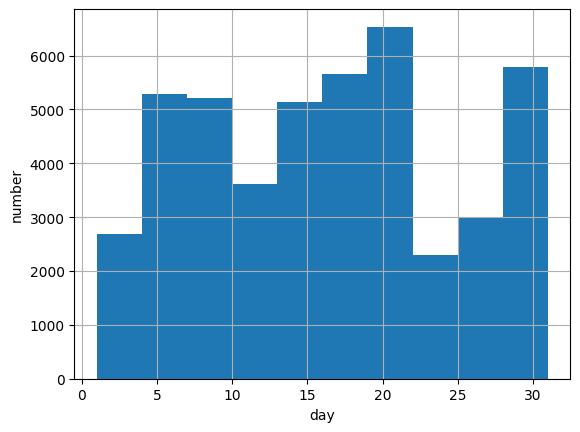

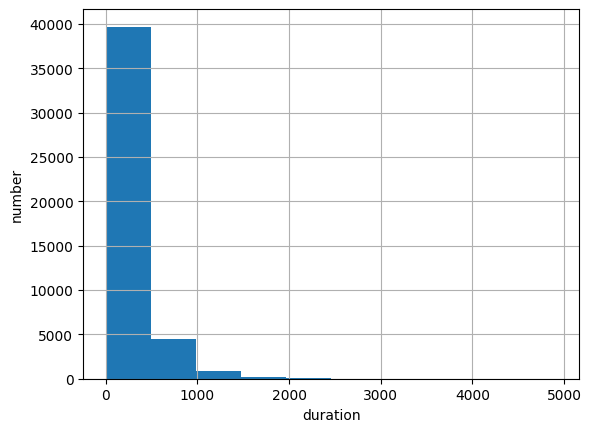

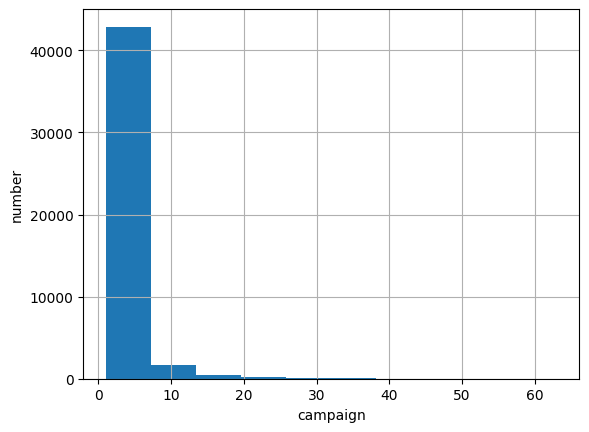

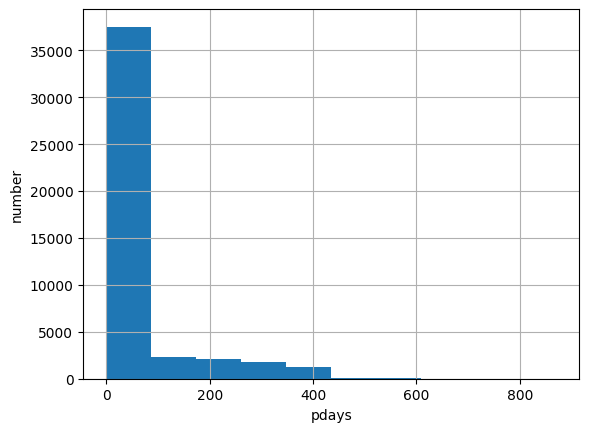

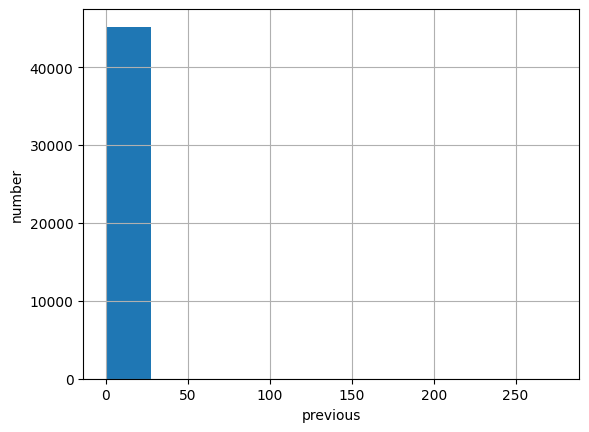

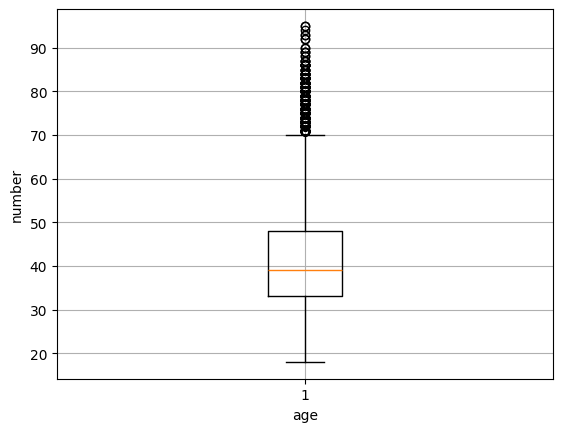

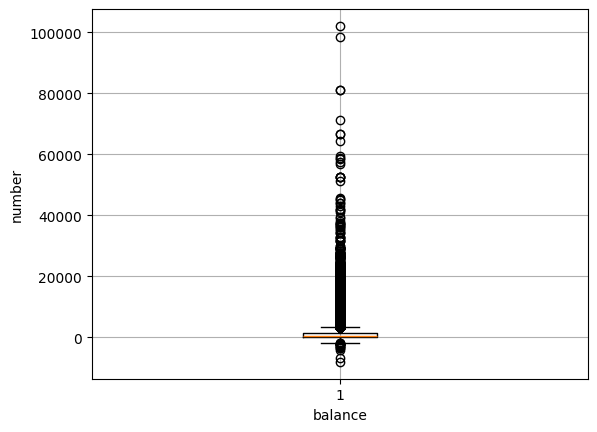

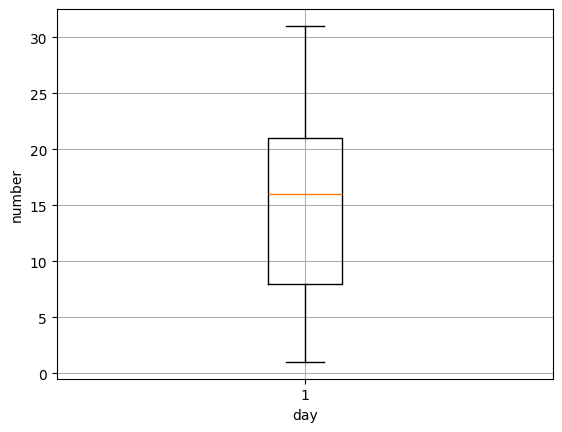

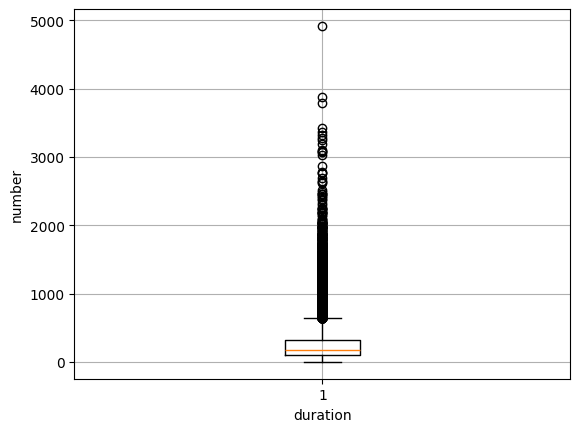

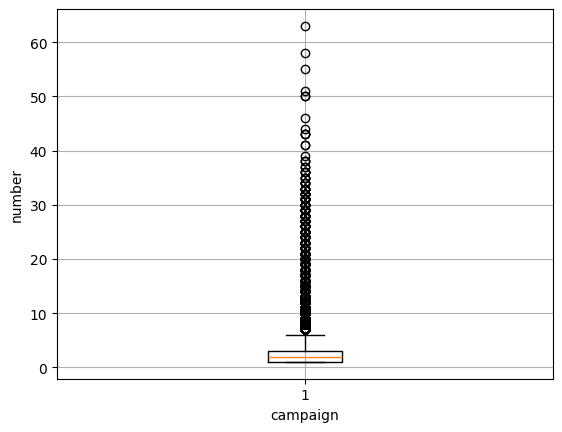

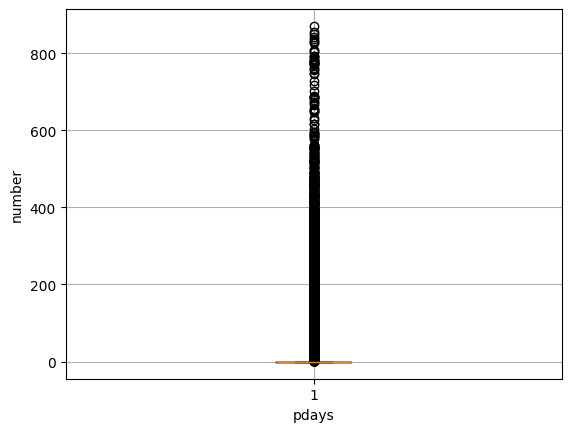

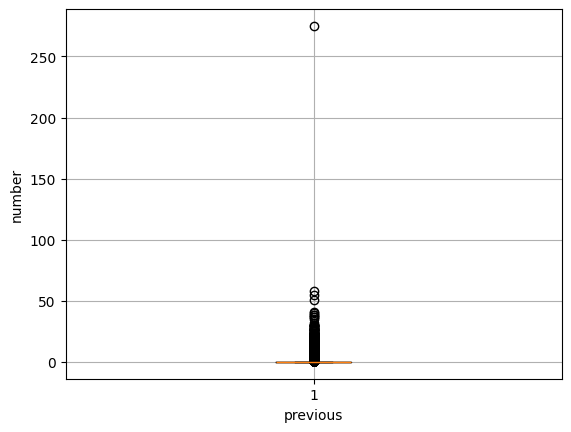

                     subscription_status  Ratio
subscription_status                            
no                                  5289   50.0
yes                                 5289   50.0
##########################################


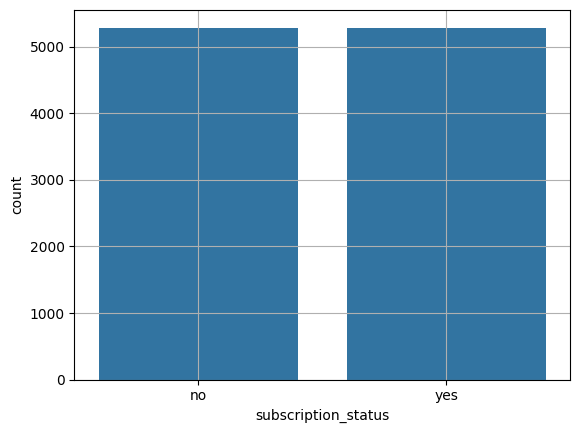

In [144]:
#############################################
# Sayısal Değişken Görselleştirme
#############################################

for c in num_cols:
  plt.hist(df[c])
  plt.xlabel(c)
  plt.ylabel("number")
  plt.grid()
  plt.show()

for c in num_cols:
  plt.boxplot(df[c])
  plt.xlabel(c)
  plt.ylabel("number")
  plt.grid()
  plt.show()

### *** Hedef Değişken İncelemesi*** ###########################################
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.grid()
        plt.show(block=True)

cat_summary(df_blncd_upld,"subscription_status",1)

In [145]:
# Hedef Değişkenin Kategorik Değişkenler ile Analizi

for col in cat_cols:
    print(f"\n{'=' * 60}")
    print(f"{col.upper()}")

    oran = pd.crosstab(
        df_blncd_upld[col],
        df_blncd_upld["subscription_status"],
        normalize="index"
    ) * 100

    print(oran.round(4))

# Hedef Değişkenin Sayısal Değişkenler ile Analizi

for col in num_cols:
    print(f"\n{'=' * 60}")
    print(f"{col.upper()}")

    oran = pd.crosstab(
        df_blncd_upld[col],
        df_blncd_upld["subscription_status"],
        normalize="index"
    ) * 100

    print(oran.round(4))


JOB
subscription_status       no      yes
job                                  
admin.               49.8410  50.1590
blue-collar          62.2601  37.7399
entrepreneur         61.4420  38.5580
housemaid            55.8704  44.1296
management           46.5269  53.4731
retired              30.3644  69.6356
self-employed        48.7671  51.2329
services             58.0682  41.9318
student              28.6472  71.3528
technician           51.0490  48.9510
unemployed           33.1126  66.8874
unknown              46.8750  53.1250

MARITAL
subscription_status       no      yes
marital                              
divorced             49.5948  50.4052
married              53.5726  46.4274
single               43.9296  56.0704

EDUCATION
subscription_status       no      yes
education                            
unknown              42.8571  57.1429
primary              57.9659  42.0341
tertiary             43.5361  56.4639
secondary            52.8483  47.1517

DEFAULT
subscription_sta

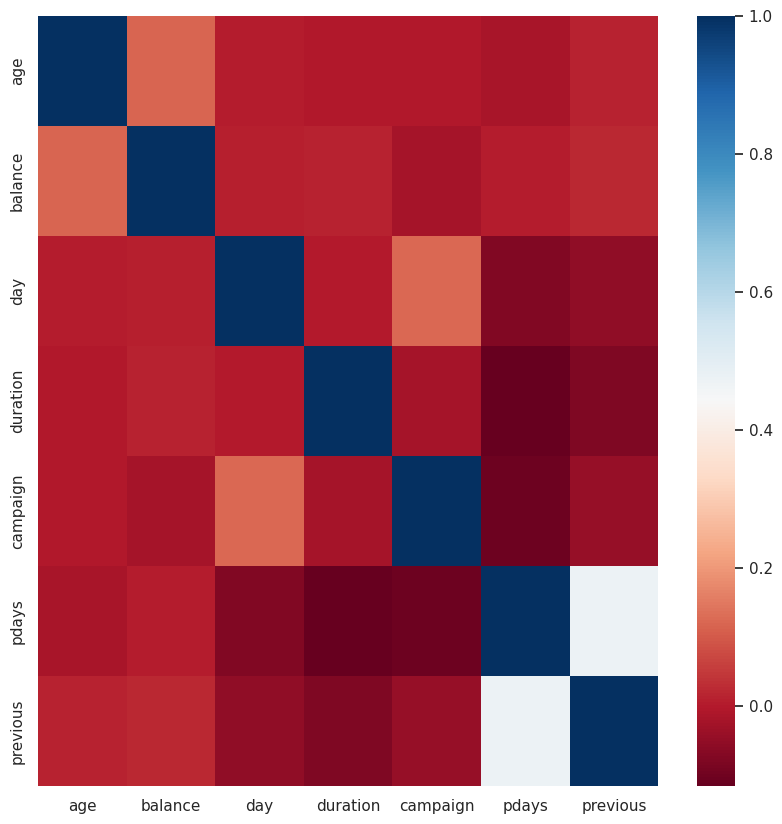

In [150]:

### *** Korelasyon Analizi (Analysis of Correlation) *** ######################

corr = df_blncd_upld[num_cols].corr()
print(corr)
sns.set(rc={'figure.figsize': (10,10)})
sns.heatmap(corr, cmap="RdBu")
plt.show()


In [157]:

### ***Yüksek Korelasyonlu Değişkenlerin Silinmesi *** ######################
# Yüksek Korelasyonlu Değişkenlerin Silinmesi

corr_matrix_abs = df_blncd_upld[num_cols].corr().abs() # korelasyon matrisinin mutlağı alındı
print(corr_matrix_abs)

sns.set(rc={'figure.figsize': (10,10)})
sns.heatmap(corr_matrix_abs, cmap="RdBu")
plt.show()
#yüksek korelasyonlu değişkenlerden arık korelasyon matrisini oluşturalım.
upper_triangle_matrix = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
print(upper_triangle_matrix)

### notes about correlation matrix: pdays-previous correlation is the highest.
### all other correlations are lower than 0.2
sns.set(rc={'figure.figsize': (10,10)})
sns.heatmap(upper_triangle_matrix, cmap="RdBu")
plt.show()

          age   balance       day  duration  campaign     pdays  previous
age       NaN  0.118888  0.003215  0.002841  0.004249  0.017421  0.013479
balance   NaN       NaN  0.007778  0.011708  0.022579  0.002870  0.022903
day       NaN       NaN       NaN  0.001899  0.119312  0.073781  0.052415
duration  NaN       NaN       NaN       NaN  0.023402  0.116158  0.081058
campaign  NaN       NaN       NaN       NaN       NaN  0.106919  0.045914
pdays     NaN       NaN       NaN       NaN       NaN       NaN  0.474386
previous  NaN       NaN       NaN       NaN       NaN       NaN       NaN


In [ ]:
# 05.09.2026 toplantı çalışma özeti

# Hasan ----pdays -1 (önceki kamanya dönemelrinde iletişime geçilmeyenlerin) olanların sayısı 8257
# KEŞİFSEL VERİ ANALİZİ öNCESİ
#
# Modelleme için veri seti BOYUTUNU hedef değişken bazında düzenleme işlemi
# BURDA subscription_status kırılımında filtreleme yapılcak.Filtreleme yapılırken,
#subscription_status no sınıfındaki değerlerinden seçilcek 5.289 probleme uygun şekilde filtreleme yapılması önemli
#ÇÖZÜM:
#1.
#no     5.289 6352
#yes     5.289
# bu şekilde çalışılması daha mantıklı gibi geldi ,sentetik veri üretmeye gerek kalmayacak


### YENİ FİKİR

#yes     (5.289,17)
 #  yes sınıfın içinden ve önceden iletişime geçilmiş olan birlikte gözlem sayısı:(1905,17) (eski müşteri)
 # yes sınıfın içinden ve önceden iletişime geçilmemiş  olan birlikte gözlem sayısı(3384,17 ) (yeni müşteri)

# yes sınıfında (vadeli hesaba açtırmaya meyilli olan müşterileri çoğu yeni müşteri)

## no (399.220,17)
#no sınıfın içinden ve önceden iletişime geçilmiş olan birlikte gözlem sayısı: (6352,17) (eski müşteri)
## no sınıfın içinden ve önceden iletişime geçilmemiş  olan birlikte gözlem sayısı: 399.220-6352=(392.868,17) (yeni müşteri)
## no sınıfını ve yes sınıfını ayrı ayrı değerlendirildiğinde ,ikisinde aynı durum söz konusu.
#Ayrı ayrı değerlendirme de iki sınıfda da eski müşteri sayısı oldukça az yeni müşteriyle kıyasla

##DENEGELİ HALE GETİRME DURUMU
# no sınıfından yapılacak işlem:
## no sınıfından (6352,17) (eski müşteri) bu gözlemden 1905
## no sınıfından (392.868,17) (yeni müşteri) bu gözlemden 3384
# olacak biçimde   no sınıfnı 5289 gözleme indirgeyelim Dengeleme sorunu ÇÖZÜLDÜ


## ayrıyetten test etmek içinde no sınıfından yaklaşık keyfi 1000 gözlem çekilebilir .
# Bu keyfi gözlemeler modeli eğitmek için kullanılacak noların içinden seçilmeyecek!.
# Seçilen bu gözlemler modei eğitmek için kullanılmayacak test etmek için kullanılacak.

## Sonuç olarak ilk iş olarak yani eda ya bile başlamadan bank-full_edited.csv veri setini alacağım.
## bunun içinden yes olanları alıp bir veri setine ekleyceğim. Bu yeni sete
## no sınıfından  ve eski müşteri olanlar içinden rastegele 1905 gözlem alcaz
# üstüne  no sınıfından  ve (yeni müşteri) olanların içinden rastegele 3384 gözlem seçeceğiz.
## elde edilen bu veri setiyle (ki shape'i 10578,17 olacak) EDA'dan başlayarak modellemeye kadar gideceğiz.
# EDA'da veri tiplerinindoğru giriliğ girlmediğine bak.
# bu durumda pdays'in model tarafından etksizi elemanmış gibi algılanacağının farkındayız.



### sandbox
df_reduced=df[(df["pdays"]-1) & (df["subscription_status"]=="no")]
df_reduced[(df["pdays"]>-1) & (df["subscription_status"]=="no")]
df_reduced=pd.concat([df_reduced,df[(df["pdays"]>-1) & (df["subscription_status"]=="yes")] ],ignore_index=True)
df_reduced.type

df_reduced_=df[(df["pdays"]==-1)& (df["subscription_status"]=="yes")]

pd.concat([datf1,datf2])
pd.concat([datf1,datf2],ignore_index=True) #ignore index girilmeyince önce
# datf1'i ilk indeksten son endekse kadar yazdırır. Sonra da datf2 nin ilk indeksinden son indeksine yazdırır.
### end of sandbx

##Oluşturlan veri seti boyutu:(10.578, 17)


# KEŞİFSEL VERİ ANALİZİ

# Adım 1 :Değişken türü doğru şekilde düzenlenecek

# Düzenleme sonucu teyit için:
# 17 değişkenin veri tipi dağılımı:
 #object tipi değişken sayısı:1 :month
 #sayısal değişken sayısı:6
 #kategorik değişken sayısı:10
  # sıralı bilgi taşıyan değişken sayısı ve ismi:1 ve education ; #kalan değişken :9 sırasız
  # 9 değişkenden :
      # ikili bilgi içeren (yes/no ) sayısı ve ismi:4: loan,default,subscription_status,housing
      # 2'den çok(2+) kategori bilgisi taşıyan ve aralarında sıra olmayan değişken sayısı 6 :contact,poutcome,job,marital,pdays(düzenlenmiş hali)
# pdays'i dzüenlereken order false olacak.
#Adım 2: Veri tipi doğru tanımlandıktan sonra yukarda daha önceki (korelasyon kadar yapılan adımlar tekrarlanacak)

#Adım 3:Adım 2^deki sonuçlar incelenecek

#Adım 4:Değişken türü bazında inceleme yapılacak
#Sayısal değişkenlerde aykırı değerler daha  önce oluşturdugumuz not üzerinden baskılanacak
#veya
#yeni oluşturulan veri setinde(10.578, 17) aykırı değer OLMAYABİLİR İNCELENECEK

#Adım 5: #kategorik değişkenler sayısal çevirme işlemi yapılacak
# ikili değişkenlerdeki (yes/no :1/0) olarak,4 değişken
      # 2'den çok(2+) kategori bilgisi taşıyan ve aralarında sıra olmayan değişken sayısı 7 :contact,poutcome,job,marutal,pdays(düzenlenmiş hali),education
      #2^den fazla kategori sahip olanlar kategorisine bağlo olarak sayısal kodlanacak(1,2,3,..şeklinde )

#Adım6:Adım 5 sayısal'a çevirilen değişkenler encoding yapılacak
# one hot encoding:ikili değişkenlerdeki (yes/no :1/0) olarak,4 değişken
# label encoding 2'den çok(2+) kategori  sahip değişkenler yapılacak
#label encoding uygularken DİKKAT SIRALI VE SIRASIZ OLANLAR DOĞRU ENCODİNG YAPILMASI ÖNEMLİ

#Adım 7: Sayısal değişkenlerimize standardizasyon işlemi yapılacak
#Min-max,Robust standardizasyon türlerin hangisi kararı verilirken gerekçesini bildirmemiz gerekiyor

#Yulduz
#Adım 8:
#ARAŞTIRMA KAPSAMINA AİT VERİ SETİ VADELİ HESAP TAHMİN modelin uygunluğu araştırılacak

#BURDA şimdi NETLEŞTİRİLMESİ GEREKEN DURUM
# elimizdeki zaman serisi veri seti ve zaman seri setine tahmin modeli çalışması yapılması DOĞRU OLUR MU?

/tmp/ipykernel_5231/4247089792.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_reduced[(df["pdays"]>-1) & (df["subscription_status"]=="no")]


AttributeError: 'DataFrame' object has no attribute 'type'

In [ ]:
df.shape

(45211, 17)

In [ ]:
print(len(df["subscription_status"].value_counts()) )

2


In [ ]:
print(100 * df["subscription_status"].value_counts() / len(df))

NameError: name 'df' is not defined